# Guida al file `domanda_ricarica_2025_per_sezione_IDI.csv`

## Scopo del notebook

Questo notebook spiega in modo operativo il dataset che ripartisce i **veicoli da ricaricare osservati a livello provinciale** tra le sezioni di censimento 2011, utilizzando:

1. la popolazione stimata in età di guida come base demografica;
2. l'Indice di Deprivazione Italiano ridotto come correttivo socioeconomico;
3. una normalizzazione separata per provincia;
4. un limite massimo demografico per sezione;
5. un eventuale arrotondamento con il metodo dei maggiori resti.

Il file contiene una riga per sezione censuaria e 32 colonne. Le colonne vengono spiegate singolarmente nelle sezioni successive.

### Avviso sull'integrità della copia allegata

La copia analizzata durante la costruzione del notebook contiene **365.304 righe dati**, mentre l'output nazionale completo ne conteneva 366.863. L'ultima riga disponibile è inoltre troncata. Il notebook include controlli automatici che evidenziano questa anomalia e le province per cui il totale ripartito non coincide più con il totale di input.

La spiegazione delle colonne resta valida; per analisi definitive è però necessario utilizzare la copia completa del CSV.

In [ ]:
# Librerie, parametri e funzioni di caricamento
from pathlib import Path
import csv
import gzip

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

# Opzione 1: lasciare None e collocare CSV e notebook nella stessa cartella.
# Opzione 2: indicare un percorso completo, per esempio:
# CSV_PATH = Path(r"C:\progetto\domanda_ricarica_2025_per_sezione_IDI.csv.gz")
# Il file si trova annidato in una cartella con lo stesso nome (creata
# probabilmente durante il download/estrazione), quindi il percorso punta
# esplicitamente al file dentro quella cartella.
CSV_PATH = Path(r"E:\project\domanda_ricarica_2025_per_sezione_IDI.csv\domanda_ricarica_2025_per_sezione_IDI.csv")

# Sono supportate sia la copia non compressa sia quella completa compressa.
CSV_FILENAMES = [
    "domanda_ricarica_2025_per_sezione_IDI.csv",
    "domanda_ricarica_2025_per_sezione_IDI.csv.gz",
]
EXPECTED_COMPLETE_ROWS = 366_863
EXPECTED_NATIONAL_EV_TOTAL = 1_370_592

# Gli identificativi sono letti come stringhe per conservare gli zeri iniziali.
IDENTIFIER_DTYPES = {
    "CODREG": "string",
    "CODPRO": "string",
    "CODCOM": "string",
    "PROCOM": "string",
    "SEZ2011": "string",
    "NSEZ": "string",
}


def resolve_csv_path(filenames, explicit_path=None):
    if explicit_path is not None:
        candidate = Path(explicit_path).expanduser()
        if candidate.exists():
            return candidate.resolve()
        raise FileNotFoundError(f"CSV_PATH non esiste: {candidate}")

    cwd = Path.cwd()
    directories = [
        cwd,
        cwd / "data",
        cwd / "upload",
        cwd.parent,
        cwd.parent / "data",
        cwd.parent / "upload",
        cwd.parent.parent / "upload",
    ]
    searched = []
    for filename in filenames:
        for directory in directories:
            candidate = directory / filename
            searched.append(str(candidate))
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError(
        "CSV non trovato. Collocare il file .csv o .csv.gz accanto al notebook "
        "oppure impostare CSV_PATH in questa cella (seconda cella del notebook, "
        "parametro CSV_PATH). "
        + f"Primo percorso controllato: {searched[0] if searched else 'nessuno'}"
    )


def normalize_identifier(series, width):
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(width)
    )


## 1. Caricamento e struttura generale

Gli identificativi territoriali non sono quantità numeriche: anche se contengono solo cifre, devono essere trattati come testo. Questo evita di perdere gli zeri iniziali di `PROCOM`, `SEZ2011` e `NSEZ`.

La cella seguente controlla:

- numero di righe e colonne;
- unicità di `SEZ2011`;
- numero di regioni e province EV;
- completezza dell'ultima riga;
- differenza rispetto alle 366.863 sezioni dell'output nazionale completo.

In [2]:
csv_path = resolve_csv_path(CSV_FILENAMES, CSV_PATH)
df = pd.read_csv(csv_path, dtype=IDENTIFIER_DTYPES, low_memory=False)

df["CODREG"] = normalize_identifier(df["CODREG"], 2)
df["CODPRO"] = normalize_identifier(df["CODPRO"], 3)
df["CODCOM"] = normalize_identifier(df["CODCOM"], 3)
df["PROCOM"] = normalize_identifier(df["PROCOM"], 6)
df["SEZ2011"] = normalize_identifier(df["SEZ2011"], 13)
df["NSEZ"] = normalize_identifier(df["NSEZ"], 7)

open_text = gzip.open if csv_path.name.lower().endswith(".gz") else open
with open_text(csv_path, "rt", encoding="utf-8-sig", newline="") as handle:
    reader = csv.reader(handle)
    physical_header = next(reader)
    physical_last_row = None
    for physical_row in reader:
        physical_last_row = physical_row

last_row_field_deficit = len(physical_header) - len(physical_last_row or [])
last_output_missing = int(
    df.tail(1)[
        [
            "veicoli_da_ricaricare_stimati_decimali",
            "veicoli_da_ricaricare_stimati_interi",
        ]
    ].isna().sum(axis=1).iloc[0]
)
overview = pd.DataFrame({
    "controllo": [
        "File utilizzato",
        "Righe dati presenti",
        "Righe attese nel file completo",
        "Differenza righe",
        "Colonne",
        "Regioni",
        "Province EV 2025",
        "SEZ2011 duplicate",
        "Campi mancanti nella riga fisica finale",
        "Stime EV mancanti nell'ultima riga",
    ],
    "risultato": [
        str(csv_path),
        len(df),
        EXPECTED_COMPLETE_ROWS,
        len(df) - EXPECTED_COMPLETE_ROWS,
        df.shape[1],
        df["REGIONE"].nunique(),
        df["Provincia_EV_2025"].nunique(),
        int(df["SEZ2011"].duplicated().sum()),
        last_row_field_deficit,
        last_output_missing,
    ],
})
display(overview)
display(df.head(3))

if len(df) != EXPECTED_COMPLETE_ROWS or last_row_field_deficit > 0:
    print("ATTENZIONE: la copia caricata non è completa; vedere la sezione 7.")
else:
    print("La struttura del file è completa.")


                                 controllo  \
0                          File utilizzato   
1                      Righe dati presenti   
2           Righe attese nel file completo   
3                         Differenza righe   
4                                  Colonne   
5                                  Regioni   
6                         Province EV 2025   
7                        SEZ2011 duplicate   
8  Campi mancanti nella riga fisica finale   
9       Stime EV mancanti nell'ultima riga   

                                                                          risultato  
0  /workspace/scratch/35a11f094ce2/upload/domanda_ricarica_2025_per_sezione_IDI.csv  
1                                                                            365304  
2                                                                            366863  
3                                                                             -1559  
4                                                              

## 2. Come è organizzato il dataset

Le 32 colonne appartengono a cinque gruppi logici:

| Gruppo | Funzione |
|---|---|
| Identificativi territoriali | Identificano regione, provincia 2011, comune e sezione |
| Raccordo provinciale | Collega le sezioni 2011 alle province utilizzate dal file EV 2025 |
| Popolazione e qualità | Descrive la base demografica e segnala sezioni particolari |
| IDI e trasformazioni | Rappresenta deprivazione, benessere e affidabilità del segnale |
| Ripartizione EV | Contiene pesi, quote, cap, totale provinciale e stime finali |

La catena di calcolo principale è:

$$
\text{popolazione in età di guida}
\rightarrow \text{peso corretto dall'IDI}
\rightarrow \text{quota provinciale}
\rightarrow \text{EV stimate nella sezione}
$$

## 3. Dizionario completo — identificativi territoriali

| Colonna | Tipo logico | Significato e uso corretto |
|---|---|---|
| `CODREG` | Identificativo testuale, 2 cifre | Codice ISTAT della regione. Va usato come chiave, non come misura numerica. |
| `REGIONE` | Testo | Denominazione della regione. Serve per lettura, filtri e aggregazioni descrittive. |
| `CODPRO` | Identificativo testuale, 3 cifre | Codice della provincia nell'assetto censuario 2011. Può non coincidere con l'assetto territoriale usato nel 2025. |
| `PROVINCIA_2011` | Testo | Denominazione della provincia a cui apparteneva la sezione nel Censimento 2011. |
| `CODCOM` | Identificativo testuale, 3 cifre | Progressivo del comune all'interno della provincia 2011. Non è univoco a livello nazionale se usato da solo. |
| `COMUNE` | Testo | Denominazione del comune censuario 2011. Può essere mancante per alcune sezioni speciali. |
| `PROCOM` | Identificativo testuale, 6 cifre | Codice comunale completo formato dal codice provinciale e dal progressivo comunale. È la chiave comunale dell'assetto 2011. |
| `SEZ2011` | Identificativo testuale, 13 cifre | Identificativo nazionale della sezione di censimento 2011. È la chiave primaria del dataset e deve essere univoca. |
| `NSEZ` | Identificativo testuale, 7 cifre | Numero progressivo della sezione all'interno del comune. Alcuni valori convenzionali identificano sezioni censuarie speciali. |

## 4. Dizionario completo — raccordo territoriale e popolazione

| Colonna | Tipo logico | Significato e uso corretto |
|---|---|---|
| `Provincia_EV_2025` | Testo | Provincia alla quale è associato il totale `veicoli_da_ricaricare` del 2025. È l'ambito effettivo della normalizzazione EV. |
| `metodo_raccordo_provincia` | Categoria | Indica come la provincia censuaria 2011 è stata collegata alla provincia EV 2025. Permette di verificare i casi non corrispondenti per semplice nome. |
| `P1` | Intero, residenti | Popolazione residente totale nella sezione secondo il Censimento 2011. È usata per i flag e per attenuare l'IDI nelle sezioni piccole. |
| `popolazione_eta_guida_stimata` | Intero, persone | Stima della popolazione potenzialmente in età di guida. È la base demografica della ripartizione EV. La variabile era già presente nel dataset sorgente e questo file non ne ricostruisce la formula. |
| `flag_abitata` | Booleano | `True` quando `P1 > 0`. Le sezioni senza residenti non ricevono domanda EV residenziale. |
| `flag_bassa_popolazione` | Booleano | `True` quando la sezione ha da 1 a 49 residenti. Non elimina la sezione, ma segnala che i rapporti IDI sono più instabili. |
| `flag_sezione_speciale` | Booleano | Identifica sezioni censuarie convenzionali tramite codici `NSEZ` speciali. Queste sezioni vengono escluse dalla ripartizione EV. |
| `flag_IDI_calcolabile` | Booleano | `True` quando la sezione è abitata e tutti i numeratori e denominatori necessari alle quattro componenti dell'IDI sono validi. |
| `motivo_IDI_non_calcolabile` | Categoria/testo | Motivo dell'assenza dell'IDI, per esempio popolazione zero oppure denominatore censuario non valido. È vuoto quando l'IDI è calcolabile. |

## 5. Dizionario completo — IDI e trasformazioni

| Colonna | Tipo logico | Significato e uso corretto |
|---|---|---|
| `IDI_ridotto_winsor` | Numero reale | Somma delle quattro componenti IDI standardizzate con mediana/IQR e limitata superiormente al percentile 99,9. Valori alti indicano maggiore deprivazione. |
| `percentile_deprivazione` | Numero tra 0 e 1 | Rango nazionale dell'IDI. Valori vicini a 1 indicano sezioni relativamente più deprivate; valori vicini a 0 sezioni meno deprivate. |
| `percentile_benessere` | Numero tra 0 e 1 | Complemento del percentile di deprivazione: `1 - percentile_deprivazione`. Valori alti indicano maggiore benessere relativo. Rimane mancante se l'IDI non è calcolabile. |
| `rango_benessere_EV` | Numero tra 0 e 1 | Variabile effettivamente usata nella ripartizione. Coincide con `percentile_benessere`; quando l'IDI manca assume 0,5, cioè un effetto neutrale. |
| `fattore_affidabilita_IDI` | Numero tra 0 e 1 | Attenua l'IDI nelle sezioni piccole: $P1/(P1+50)$. È prossimo a 0 per pochissimi residenti e tende a 1 nelle sezioni grandi. |
| `moltiplicatore_IDI_EV` | Numero positivo | Correttivo socioeconomico: $1+0{,}30\times fattore\_affidabilita\times(2\times rango\_benessere-1)$. Valori sopra 1 aumentano il peso pro capite; valori sotto 1 lo riducono. |

## 6. Dizionario completo — pesi e risultati EV

| Colonna | Tipo logico | Significato e uso corretto |
|---|---|---|
| `flag_eleggibile_EV` | Booleano | `True` se la sezione ha residenti, popolazione in età di guida positiva e non è speciale. Un IDI mancante non rende la sezione ineleggibile: viene usato il rango neutrale 0,5. |
| `peso_EV` | Numero non negativo | Peso grezzo della sezione: `popolazione_eta_guida_stimata × moltiplicatore_IDI_EV` se eleggibile, altrimenti 0. |
| `quota_peso_provincia` | Numero tra 0 e 1 | Quota del peso della sezione sul totale dei pesi della sua `Provincia_EV_2025`. In un file completo le quote sommano a 1 in ciascuna provincia. |
| `cap_EV_sezione` | Numero non negativo | Massimo di plausibilità assegnabile alla sezione. Con il parametro adottato equivale alla popolazione stimata in età di guida per le sezioni eleggibili; vale 0 per le altre. |
| `flag_cap_raggiunto` | Booleano | `True` se la stima decimale raggiunge il cap. Se un cap viene raggiunto, l'eccedenza è redistribuita alle altre sezioni provinciali. |
| `EV_PROVINCIALE` | Intero, veicoli | Totale `veicoli_da_ricaricare` osservato per la provincia EV 2025, ripetuto su tutte le righe della provincia. **Non deve essere sommato direttamente su tutte le sezioni.** |
| `veicoli_da_ricaricare_stimati_decimali` | Numero reale, veicoli attesi | Stima principale della domanda EV nella sezione. È un valore atteso e può essere frazionario. In un file completo la somma provinciale coincide con `EV_PROVINCIALE`. |
| `veicoli_da_ricaricare_stimati_interi` | Intero, veicoli | Versione intera ottenuta con il metodo dei maggiori resti. Conserva il totale provinciale, ma introduce arrotondamenti locali. |

In [3]:
# Dizionario anche in forma tabellare, utile per ricerche e controlli
dictionary_records = [
    ("Territorio", "CODREG", "ID testo (2)", "Codice ISTAT della regione."),
    ("Territorio", "REGIONE", "testo", "Denominazione della regione."),
    ("Territorio", "CODPRO", "ID testo (3)", "Codice della provincia nell'assetto 2011."),
    ("Territorio", "PROVINCIA_2011", "testo", "Denominazione della provincia censuaria 2011."),
    ("Territorio", "CODCOM", "ID testo (3)", "Progressivo del comune nella provincia 2011."),
    ("Territorio", "COMUNE", "testo", "Denominazione del comune censuario 2011."),
    ("Territorio", "PROCOM", "ID testo (6)", "Codice comunale completo 2011."),
    ("Territorio", "SEZ2011", "ID testo (13)", "Chiave nazionale univoca della sezione 2011."),
    ("Territorio", "NSEZ", "ID testo (7)", "Progressivo della sezione nel comune."),
    ("Raccordo", "Provincia_EV_2025", "categoria", "Provincia usata per il totale EV 2025."),
    ("Raccordo", "metodo_raccordo_provincia", "categoria", "Metodo di raccordo 2011-2025."),
    ("Popolazione", "P1", "intero", "Residenti totali nella sezione."),
    ("Popolazione", "popolazione_eta_guida_stimata", "intero", "Base demografica potenzialmente automobilistica."),
    ("Qualità", "flag_abitata", "booleano", "P1 maggiore di zero."),
    ("Qualità", "flag_bassa_popolazione", "booleano", "Da 1 a 49 residenti."),
    ("Qualità", "flag_sezione_speciale", "booleano", "Sezione censuaria convenzionale/speciale."),
    ("Qualità", "flag_IDI_calcolabile", "booleano", "Disponibilità delle quattro componenti IDI."),
    ("Qualità", "motivo_IDI_non_calcolabile", "categoria", "Motivo dell'IDI mancante."),
    ("IDI", "IDI_ridotto_winsor", "reale", "IDI ridotto robusto; alto = più deprivazione."),
    ("IDI", "percentile_deprivazione", "reale [0,1]", "Rango nazionale di deprivazione."),
    ("IDI", "percentile_benessere", "reale [0,1]", "Uno meno il percentile di deprivazione."),
    ("IDI", "rango_benessere_EV", "reale [0,1]", "Benessere usato nel peso; 0,5 se IDI mancante."),
    ("IDI", "fattore_affidabilita_IDI", "reale [0,1]", "P1 diviso P1 più 50."),
    ("IDI", "moltiplicatore_IDI_EV", "reale positivo", "Correttivo socioeconomico del peso."),
    ("Allocazione", "flag_eleggibile_EV", "booleano", "Sezione ammessa alla ripartizione EV."),
    ("Allocazione", "peso_EV", "reale >= 0", "Base demografica moltiplicata per il correttivo IDI."),
    ("Allocazione", "quota_peso_provincia", "reale [0,1]", "Quota del peso provinciale."),
    ("Allocazione", "cap_EV_sezione", "reale >= 0", "Massimo EV assegnabile alla sezione."),
    ("Allocazione", "flag_cap_raggiunto", "booleano", "Indica il raggiungimento del cap."),
    ("Risultato", "EV_PROVINCIALE", "intero", "Totale EV provinciale ripetuto sulle righe."),
    ("Risultato", "veicoli_da_ricaricare_stimati_decimali", "reale", "Valore atteso sezionale principale."),
    ("Risultato", "veicoli_da_ricaricare_stimati_interi", "intero", "Allocazione intera con maggiori resti."),
]
data_dictionary = pd.DataFrame(
    dictionary_records,
    columns=["gruppo", "colonna", "tipo_logico", "descrizione_breve"],
)

missing_descriptions = set(df.columns) - set(data_dictionary["colonna"])
extra_descriptions = set(data_dictionary["colonna"]) - set(df.columns)
assert not missing_descriptions, f"Colonne non documentate: {sorted(missing_descriptions)}"
assert not extra_descriptions, f"Descrizioni senza colonna: {sorted(extra_descriptions)}"
assert len(data_dictionary) == len(df.columns) == 32

display(data_dictionary)
print("Tutte le 32 colonne sono documentate.")


         gruppo                                 colonna     tipo_logico  \
0    Territorio                                  CODREG    ID testo (2)   
1    Territorio                                 REGIONE           testo   
2    Territorio                                  CODPRO    ID testo (3)   
3    Territorio                          PROVINCIA_2011           testo   
4    Territorio                                  CODCOM    ID testo (3)   
5    Territorio                                  COMUNE           testo   
6    Territorio                                  PROCOM    ID testo (6)   
7    Territorio                                 SEZ2011   ID testo (13)   
8    Territorio                                    NSEZ    ID testo (7)   
9      Raccordo                       Provincia_EV_2025       categoria   
10     Raccordo               metodo_raccordo_provincia       categoria   
11  Popolazione                                      P1          intero   
12  Popolazione          

## 7. Controlli di qualità sul file allegato

`EV_PROVINCIALE` è ripetuto su ogni sezione; per ricostruire il totale nazionale di input bisogna prendere **un solo valore per provincia**, non sommare la colonna riga per riga.

Per ogni provincia, un file completo deve rispettare:

$$
\sum_i EV^{decimali}_i=EV_{provincia}
$$

e:

$$
\sum_i EV^{interi}_i=EV_{provincia}
$$

La cella seguente controlla queste identità. Sulla copia allegata segnala due province incomplete (`NUORO` e `SUD SARDEGNA`), coerentemente con il fatto che il file termina durante le righe della Sardegna.

In [4]:
# Riconciliazione dei totali provincia per provincia
province_check = (
    df.groupby("Provincia_EV_2025", as_index=False)
    .agg(
        EV_input=("EV_PROVINCIALE", "first"),
        EV_ripartite_decimali=("veicoli_da_ricaricare_stimati_decimali", "sum"),
        EV_ripartite_intere=("veicoli_da_ricaricare_stimati_interi", "sum"),
        sezioni_presenti=("SEZ2011", "size"),
        sezioni_eleggibili=("flag_eleggibile_EV", "sum"),
    )
)
province_check["differenza_decimali"] = (
    province_check["EV_ripartite_decimali"] - province_check["EV_input"]
)
province_check["differenza_intere"] = (
    province_check["EV_ripartite_intere"] - province_check["EV_input"]
)

problem_provinces = province_check.loc[
    province_check["differenza_decimali"].abs().gt(1e-6)
    | province_check["differenza_intere"].abs().gt(0)
].copy()

national_input = province_check["EV_input"].sum()
national_decimal = df["veicoli_da_ricaricare_stimati_decimali"].sum()
national_integer = df["veicoli_da_ricaricare_stimati_interi"].sum()

national_check = pd.DataFrame({
    "metrica": [
        "Totale EV provinciale atteso",
        "Somma stime decimali presenti",
        "Somma stime intere presenti",
        "EV decimali mancanti rispetto all'input",
        "EV intere mancanti rispetto all'input",
    ],
    "valore": [
        national_input,
        national_decimal,
        national_integer,
        national_decimal - national_input,
        national_integer - national_input,
    ],
})
display(national_check)
display(problem_provinces)

print("Ultima riga disponibile:")
display(df.tail(1))


                                   metrica           valore
0             Totale EV provinciale atteso 1,370,592.000000
1            Somma stime decimali presenti 1,368,258.621595
2              Somma stime intere presenti 1,368,245.000000
3  EV decimali mancanti rispetto all'input    -2,333.378405
4    EV intere mancanti rispetto all'input    -2,347.000000
   Provincia_EV_2025  EV_input  EV_ripartite_decimali  EV_ripartite_intere  \
60             NUORO      1824           1,517.437247         1,515.000000   
89      SUD SARDEGNA      3154           1,127.184349         1,116.000000   

    sezioni_presenti  sezioni_eleggibili  differenza_decimali  \
60              1113                 940          -306.562753   
89               677                 597        -2,026.815651   

    differenza_intere  
60        -309.000000  
89      -2,038.000000  
Ultima riga disponibile:
       CODREG   REGIONE CODPRO PROVINCIA_2011 CODCOM COMUNE  PROCOM  \
365303     20  Sardegna    105      Oglia

### Interpretazione dell'anomalia

Nella copia allegata:

- mancano 1.559 sezioni rispetto all'output completo;
- l'ultima riga è troncata e non contiene le due stime finali;
- la somma delle stime è incompleta per `NUORO` e `SUD SARDEGNA`;
- non è quindi corretto usare questa specifica copia per aggregazioni nazionali definitive.

Il problema riguarda la completezza fisica del file, non le formule delle colonne. Una copia completa deve avere 366.863 righe dati e riconciliare esattamente tutte le 107 province.

## 8. Esempio di lettura di una riga

Per interpretare una sezione, conviene leggere le colonne in questo ordine:

1. **Dove si trova?** `REGIONE`, `PROVINCIA_2011`, `COMUNE`, `SEZ2011`.
2. **A quale totale EV appartiene?** `Provincia_EV_2025` ed `EV_PROVINCIALE`.
3. **Quanto è grande?** `P1` e `popolazione_eta_guida_stimata`.
4. **Quanto è benestante/deprivata?** `IDI_ridotto_winsor` e `percentile_benessere`.
5. **Quanto è affidabile il segnale IDI?** `fattore_affidabilita_IDI`.
6. **Quale peso riceve?** `moltiplicatore_IDI_EV`, `peso_EV`, `quota_peso_provincia`.
7. **Qual è il risultato?** stima decimale e stima intera.

La stima decimale va interpretata come **valore atteso**. Per esempio, 0,25 non significa un quarto di automobile fisica: significa che, ripetendo idealmente l'allocazione su molte aree simili, quella sezione contribuirebbe in media per 0,25 veicoli.

In [5]:
# Esempi: sezione grande, sezione piccola e sezione non eleggibile
example_columns = [
    "REGIONE", "Provincia_EV_2025", "COMUNE", "SEZ2011", "P1",
    "popolazione_eta_guida_stimata", "flag_IDI_calcolabile",
    "percentile_benessere", "rango_benessere_EV",
    "fattore_affidabilita_IDI", "moltiplicatore_IDI_EV",
    "flag_eleggibile_EV", "peso_EV", "quota_peso_provincia",
    "veicoli_da_ricaricare_stimati_decimali",
    "veicoli_da_ricaricare_stimati_interi",
]

large_example = df.loc[df["flag_eleggibile_EV"]].nlargest(1, "P1")
small_example = df.loc[
    df["flag_eleggibile_EV"] & df["P1"].between(1, 2)
].head(1)
ineligible_example = df.loc[~df["flag_eleggibile_EV"]].head(1)

examples = pd.concat(
    [large_example, small_example, ineligible_example],
    keys=["sezione_grande", "sezione_1_2_residenti", "non_eleggibile"],
)
display(examples[example_columns])


                               REGIONE Provincia_EV_2025        COMUNE  \
sezione_grande        231972     Lazio              ROMA          Roma   
sezione_1_2_residenti 54      Piemonte            TORINO  Ala di Stura   
non_eleggibile        33      Piemonte            TORINO       Airasca   

                                    SEZ2011    P1  \
sezione_grande        231972  0580911090020  7647   
sezione_1_2_residenti 54      0010030000023     1   
non_eleggibile        33      0010020000011     1   

                              popolazione_eta_guida_stimata  \
sezione_grande        231972                           7298   
sezione_1_2_residenti 54                                  1   
non_eleggibile        33                                  0   

                              flag_IDI_calcolabile  percentile_benessere  \
sezione_grande        231972                  True              0.000499   
sezione_1_2_residenti 54                      True              0.998543   
non_elegg

## 9. Distribuzioni e controlli interpretativi

Tre distribuzioni sono particolarmente utili:

- `moltiplicatore_IDI_EV`: mostra quanto l'IDI modifica il peso demografico;
- `veicoli_da_ricaricare_stimati_decimali`: mostra la domanda sezionale attesa;
- `flag_eleggibile_EV`: distingue le sezioni che partecipano alla ripartizione.

Per rendere leggibile il grafico della domanda, l'istogramma è limitato al percentile 99: i valori più elevati restano nel dataset ma non allargano eccessivamente l'asse.

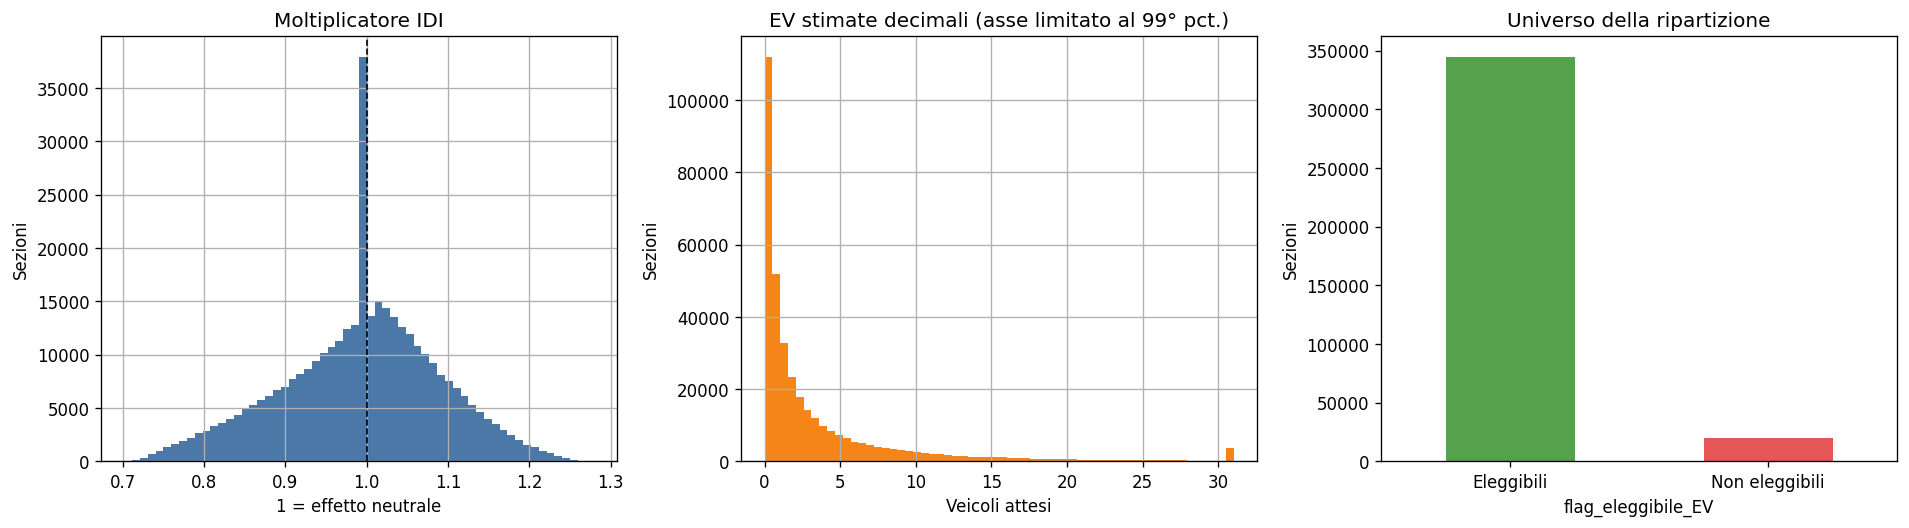

In [6]:
# Grafici descrittivi
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df["moltiplicatore_IDI_EV"].hist(bins=60, ax=axes[0], color="#4C78A8")
axes[0].axvline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Moltiplicatore IDI")
axes[0].set_xlabel("1 = effetto neutrale")
axes[0].set_ylabel("Sezioni")

ev_values = df["veicoli_da_ricaricare_stimati_decimali"].dropna()
ev_q99 = ev_values.quantile(0.99)
ev_values.clip(upper=ev_q99).hist(bins=60, ax=axes[1], color="#F58518")
axes[1].set_title("EV stimate decimali (asse limitato al 99° pct.)")
axes[1].set_xlabel("Veicoli attesi")
axes[1].set_ylabel("Sezioni")

eligibility_counts = (
    df["flag_eleggibile_EV"]
    .value_counts()
    .rename(index={True: "Eleggibili", False: "Non eleggibili"})
)
eligibility_counts.plot.bar(ax=axes[2], color=["#54A24B", "#E45756"], rot=0)
axes[2].set_title("Universo della ripartizione")
axes[2].set_ylabel("Sezioni")

plt.tight_layout()
plt.show()


## 10. Quale colonna usare?

| Esigenza | Colonna consigliata |
|---|---|
| Mappa continua della domanda potenziale | `veicoli_da_ricaricare_stimati_decimali` |
| Conteggio intero per report operativo | `veicoli_da_ricaricare_stimati_interi` |
| Graduatoria socioeconomica | `percentile_benessere` o `percentile_deprivazione` |
| Analisi dell'effetto IDI | `moltiplicatore_IDI_EV` |
| Quota della domanda provinciale | `quota_peso_provincia` |
| Filtrare le sezioni utilizzabili | `flag_eleggibile_EV` |
| Controllare qualità dell'IDI | `flag_IDI_calcolabile` e `motivo_IDI_non_calcolabile` |
| Audit del raccordo territoriale | `Provincia_EV_2025` e `metodo_raccordo_provincia` |

### Regole da ricordare

1. non sommare `EV_PROVINCIALE` sulle righe;
2. aggregare le stime usando `Provincia_EV_2025`, non necessariamente `PROVINCIA_2011`;
3. preferire la stima decimale per analisi statistiche;
4. mantenere le sezioni non eleggibili nel dataset con stima zero;
5. verificare sempre i totali provinciali prima di pubblicare un risultato;
6. sostituire la copia allegata con il CSV completo prima delle analisi definitive.

In [7]:
# Controlli finali della documentazione e del dataset
assert list(data_dictionary["colonna"]) == list(df.columns), (
    "Il dizionario contiene tutte le colonne ma non nello stesso ordine del CSV."
)
assert df["SEZ2011"].is_unique
assert df["rango_benessere_EV"].between(0, 1).all()
assert df["fattore_affidabilita_IDI"].between(0, 1).all()
assert df["moltiplicatore_IDI_EV"].gt(0).all()
assert df["peso_EV"].ge(0).all()
assert df["cap_EV_sezione"].ge(0).all()

print("Dizionario completo: 32 colonne su 32.")
print(f"Righe presenti nella copia: {len(df):,}")
print(f"Righe mancanti rispetto all'output completo: {EXPECTED_COMPLETE_ROWS - len(df):,}")
print(f"Province con riconciliazione non valida: {len(problem_provinces)}")
print("Il notebook è stato eseguito correttamente.")


Dizionario completo: 32 colonne su 32.
Righe presenti nella copia: 365,304
Righe mancanti rispetto all'output completo: 1,559
Province con riconciliazione non valida: 2
Il notebook è stato eseguito correttamente.
